# Research Notebook
## Arthana Sri Renganathan
## Date: February 09 - February 27, 2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

- We created a single script to run the Hernquist potential and rotation curve approximation and printed for all galaxies (script to run and save galaxy plots **baryon_fit_script-FINAL.py**)
- Saved the *Mb* and *a* parameters in a CSV file (code to save in CSV **baryon_parameters_csv_final.py**, CSV file name: **hernquist_fits_component.csv**)
- Wrote a code that can be imported into a separate notebook by the Data team so they can plot and calculate the Hernquist baryon potential for each galaxy individually using the galaxyID (inside **final_baryon_component.py**).
- Made sure the above code was separated for the bulge component.
- Made trace and corner plots using emcee and h5py and compared results with group members.

## Motivation:

Primarily, the single script will allow easier access to the baryon potential functions for the MCMC code run by the Data team. The printed plots with the separated bulge component are good for visually analysing how much the bulge component affects the potentials and rotation curves. Furthermore, the goal is to check that the parameters are well-suited for the functions and to use them in the final MCMC code. The trace plots and corner plots give us an idea of the convergence of r1 (radius, M200, and c).

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

Our primary task was to combine a script that would print out the baryon function plots and save them in a folder. The code can be found under the same repository (repo) and is called __baryon_fit_script-FINAL.py__ (written by me and ChatGPT[1]). Essentially, this takes the galaxyID of a galaxy and plots the rotation curve and baryonic potential with an edition of separating the bulge components. The galaxies were also separated into 2 folders: bulge and non-bulge components.

Next, I've created a script to save all the *Mb* and *a* parameters from the functions provided in __baryon_fit_script-FINAL.py__ (written by me and ChatGPT[1]). This filename is called **baryon_parameters_csv_final.py** and is provided in the same repo. It will use the gamma values (mass-to-light ratios) and a curve_fit function from scipy to guess the best fit *Mb* and *a* values (lines 80-108). It will separate the bulge components as well. The values are saved under **hernquist_fits_component.csv**.

Finally, an emcee code was used to plot trace and corner plots. The code is given below:

**emcee code for Trace Plots and Corner Plots**

    import numpy as np
    import matplotlib.pyplot as plt
    import emcee
    import corner
    import h5py
    
    filename = "UGC02953_sph_mcmc_nw_32_ni_10000.h5"
    
    backend = emcee.backends.HDFBackend(filename)
    
    nwalkers, nsteps, ndim = backend.get_chain().shape
    
    print("Walkers:", nwalkers)
    print("Steps:", nsteps)
    print("Dimensions:", ndim)
    
    #chains
    
    burnin = int(0.5 * nsteps)
    
    samples = backend.get_chain(discard=burnin, flat=False)
    flat_samples = backend.get_chain(discard=burnin, flat=True)

    # trace plots
    
    labels = ["log_r1", "log_M200", "delta_log_c"]
    
    fig, axes = plt.subplots(ndim, figsize=(8, 6), sharex=True)
    
    for i in range(ndim):
        axes[i].plot(samples[:, :, i], alpha=0.3)
        axes[i].set_ylabel(labels[i])
    
    axes[-1].set_xlabel("Step Number")
    plt.suptitle("Trace Plots")
    plt.tight_layout()
    plt.show()
    
    # corner plot
    
    fig = corner.corner(
        flat_samples,
        labels=labels,
        show_titles=True,
        quantiles=[0.16, 0.5, 0.84],
        range=[
            (0, 1),          # log_r1
            (12.1, 12.17),    # log_M200
            (0.36, 0.4)      # delta_log_c])
    
    plt.show()
    
    # param
    
    medians = np.median(flat_samples, axis=0)
    
    log_r1_best, log_M200_best, delta_log_c_best = medians
    
    print("\nBest-fit parameters (median posterior):")
    print("log_r1 =", log_r1_best)
    print("log_M200 =", log_M200_best)
    print("delta_log_c =", delta_log_c_best)

To start, r1 represents the SIDM core radius scale, where interactions within this threshold become isothermal, and beyond this threshold, the halo behaves like the NFW (Navarro-Frenck-White) profile. It should become positive and span orders of magnitude in the plots. M200 represents the total halo mass inside the radius with a density 200x higher than its normal density. Higher masses lead to higher velocities on plots. c is the mass-concentration relation and measures how concentrated a region in the halo is [2]

The trace plots are a way to visualize the MCMC step working. We want to be able to converge each parameter separately for the MCMC. The corner plots on the diagonal side are a 1D representation of each parameter. It is expected to see bell-shaped curves with some width (uncertainty) if the initial parameter approximations are set well. The off-diagonal is a 2D representation of each parameter, where it correlates 2 variables (M200 and c, r1 and c, etc.). We should expect to see an oval shape, meaning good constraints. I initially got an L-shape graph, which shows degeneracy (meaning the value is not within the limits of the parameters, and so it bunches up on the axes). To fix this, one must change the initial parameters for a better fit [3]

# 3: So what? (What does it mean?)
## Describe your results
Below, I have provided a graph of the potential and rotation curve of **UGC09133**. This galaxy has a bulge component, so you can see the role the bulge has in the potential and rotation curve (RC).

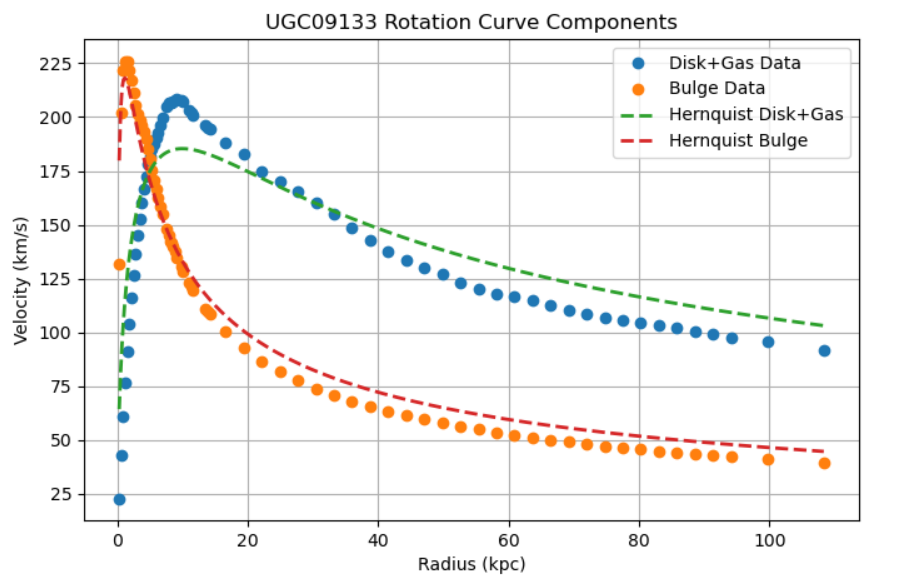

*Figure 1: Hernquist rotation curve comparison to observational data of the galaxy UGC09133.*

The Hernquist RC fit nicely with the data. The bulge component also plays a significant role in the halo's center, and has a greater effect on the M200 component.

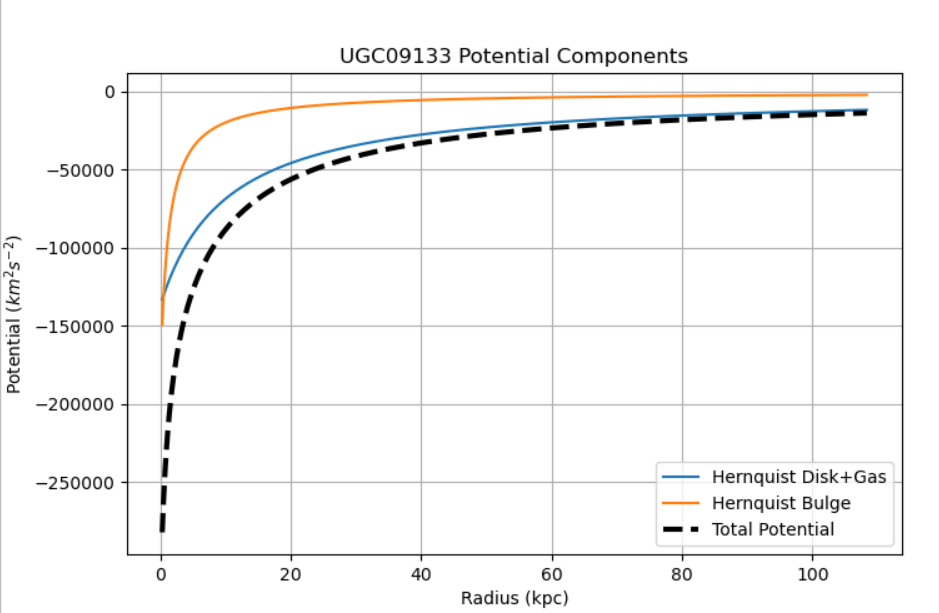

*Figure 2: Hernquist potential curve comparison to observational data of the galaxy UGC09133.*

The potential fits well in Figure 2 as well. The bulge component has a steeper potential in the initial radii, as expected from the RC plot. High velocity away from the halo's center means a faster drop rate for the potential.

Below, I have provided some images of the trace and corner plots.

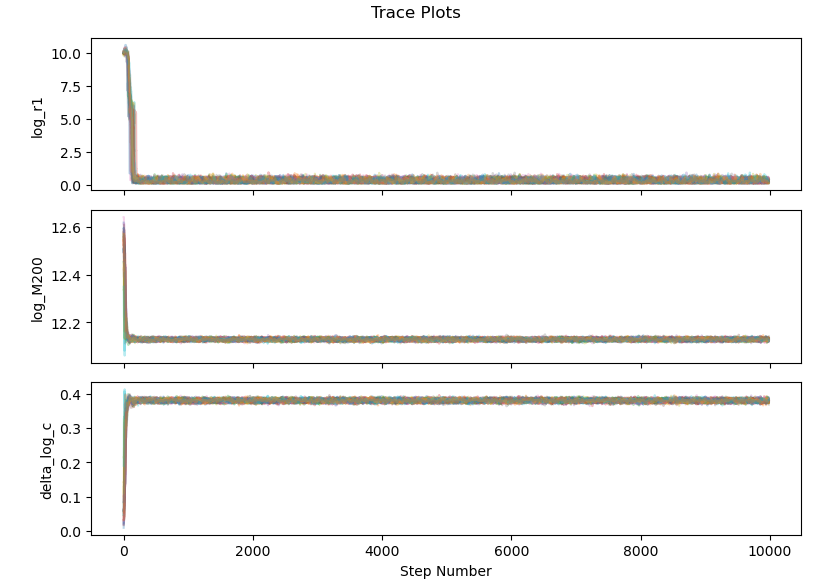

*Figure 3: Trace Plot for MCMC run and convergence testing of parameters r1, M200, and c.*

The trace plots show a stable chain (no burn-in) with no long drift patterns for all parameters, which shows good convergence. All the walkers are overlapping and do not become stuck.

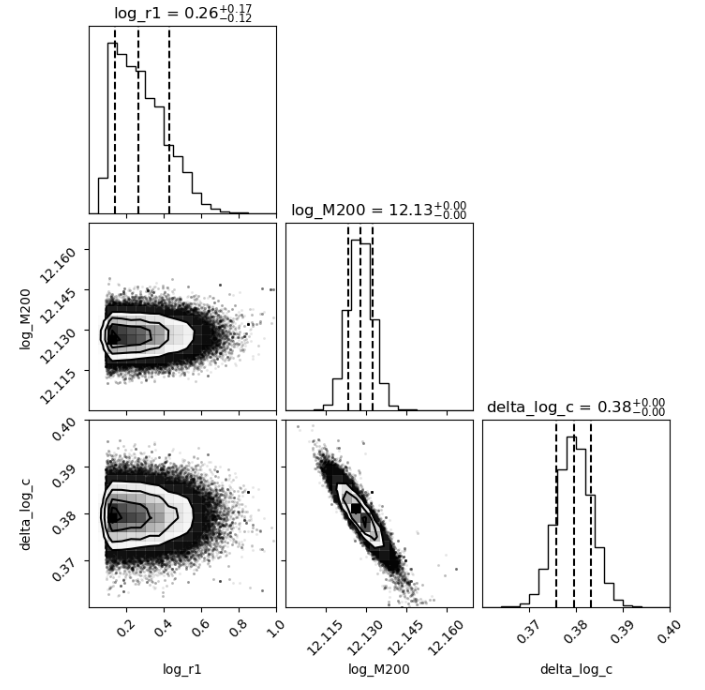

*Figure 4: Corner Plot for convergence testing of parameters r1, M200, and c.*

The corner plot further confirms the well-constrained patterns in Figure 4. The 1D distribution of the Gaussian curves is smooth and supports reasonable uncertainties (width). The 2D oval patterns show good correlations between 2 variables and no longer show L-shaped boundaries. These plots suggest that the SIDM halo parameters are a statistically consistent description of a galaxy's rotation curve. We can further confirm this with the output given by the emcee code below:

**Best-fit parameters (median posterior):**
log_r1 = 0.2619558020795952, log_M200 = 12.127847089210256, delta_log_c = 0.3795091812292443

Using the formula r1 = $10^{0.262}$ we get approximately 1.83 kpc. This is the region for SIDM interactions. Using the same equation, M200 = 1.34 x $10^{12}$ $M_o$ (reasonable for a large galaxy [4], and c is around 2.4 (2.4x higher than the mass-concentration relation predicts).

# 4. Now what? (What's next?)
## Plan for the next week

The plan for next week is to run the best-fit model plots for the emcee code to see if it matches the current rotation curve data. Our group will combine the code into a single script for accessible use by the Data team. I will also continue to make comparisons between the Mb and a parameters between the bulge components and my group members' results.

# 5. Bibliography

[1] ChatGPT - Baryonic Potential Function. (2026). ChatGPT. https://chatgpt.com/share/69895373-28ec-8005-9c5f-04447668b541

[2] Jia, Z., Jiang, F., Li, S., Li, R., Wang, J., & Zhu, L. (2026). An Enhanced Isothermal Jeans Approach to Constraining Dark Matter Self-Interactions from Galactic Kinematics. ArXiv.org. https://arxiv.org/abs/2601.17118

[3] Foreman-Mackey, D., Hogg, D. W., Lang, D., & Goodman, J. (2013). emcee: The MCMC Hammer. Publications of the Astronomical Society of the Pacific, 125(925), 306–312. https://doi.org/10.1086/670067

[4] NASA Hubble Mission Team. (2019, March 7). What Does the Milky Way Weigh? Hubble and Gaia Investigate - NASA Science. Science.nasa.gov. https://science.nasa.gov/missions/hubble/what-does-the-milky-way-weigh-hubble-and-gaia-investigate/